In [4]:
import pandas as pd
import matplotlib.pyplot as plt

/tmp/ipykernel_624/2001757453.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([0, 1000, 2000, 3000, 4000],rotation=0, fontsize=10)


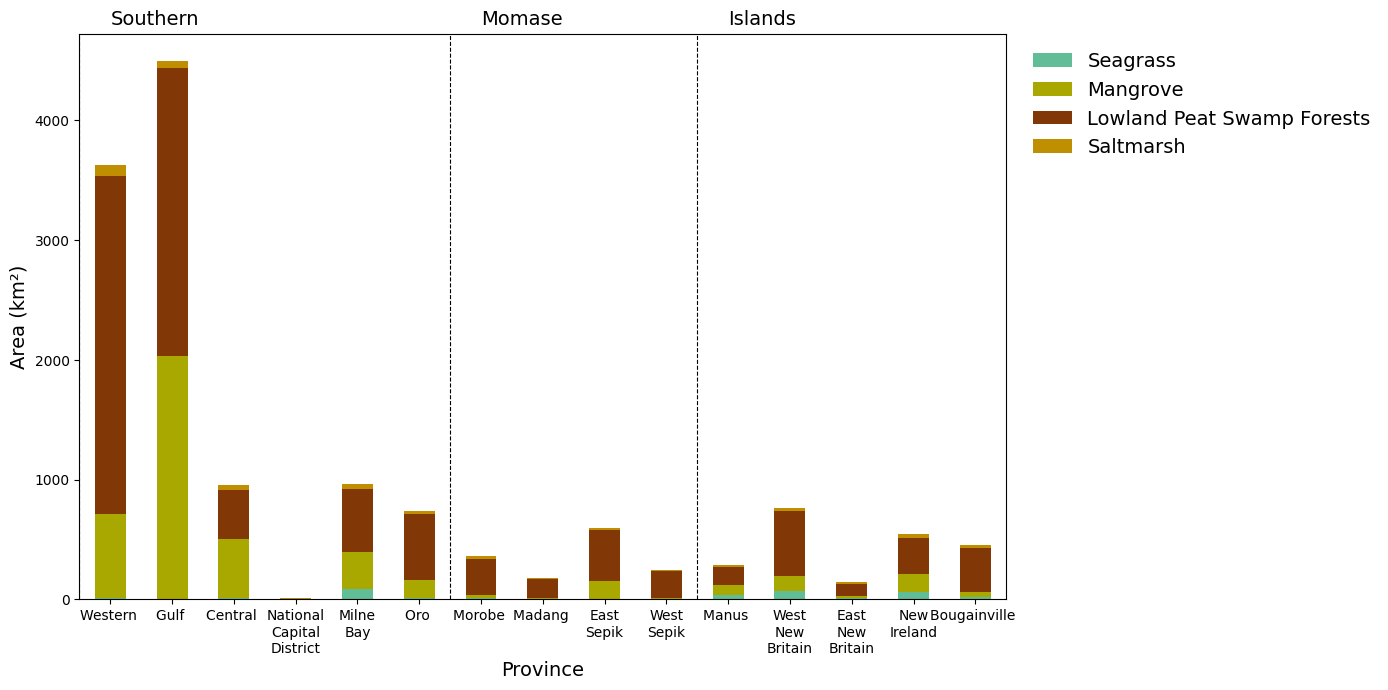

In [18]:
# Create DataFrame
data = pd.read_csv('./extent_km2.csv')

df = pd.DataFrame(data)

# --- Clean column names ---
df.columns = df.columns.str.strip()

# --- Habitat columns ---
habitats = ['Seagrass', 'Mangrove', 'Lowland Peat Swamp Forests', 'Saltmarsh']

# --- Set Province as index ---
df.set_index('Province', inplace=True)

# --- Wrap province names with 2 or more words ---
def wrap_label(label):
    if len(label.split()) >= 2:
        return '\n'.join(label.split())
    return label

xticklabels_wrapped = [wrap_label(label) for label in df.index]

# --- Define custom RGB color scheme ---
PNG_BCE_COLOUR_SCHEME = {
    'Mangrove': (168, 168, 0, 255),
    'Lowland Peat Swamp Forests': (130, 56, 6, 255),
    'Saltmarsh': (191, 142, 1, 255),
    'Seagrass': (96, 189, 150, 255),
}

# Convert to RGB (0–1) for matplotlib
color_map = [tuple(c / 255 for c in PNG_BCE_COLOUR_SCHEME[h][:3]) for h in habitats]

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 7))
bars = df[habitats].plot(
    kind='bar',
    stacked=True,
    color=color_map,
    ax=ax
)

# --- Add region separator lines and labels ---
regions = df['Region'].values
prev_region = None
xticks = list(range(len(df)))

for i, (label, region) in enumerate(zip(df.index, regions)):
    if region != prev_region:
        ax.axvline(i - 0.5, color='black', linestyle='--', linewidth=0.8)
        ax.text(i, ax.get_ylim()[1] * 1.01, region, ha='left', va='bottom', fontsize=14, rotation=0)
        prev_region = region

# --- Customize ---
ax.set_xlabel('Province', fontsize=14)
ax.set_ylabel('Area (km²)', fontsize=14)
ax.set_yticklabels([0, 1000, 2000, 3000, 4000],rotation=0, fontsize=10)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels_wrapped, rotation=0, fontsize=10)

# --- Clean legend with colored boxes ---
handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=habitats,
    loc='upper left',
    bbox_to_anchor=(1.01, 1),
    frameon=False, 
    fontsize=14
)

plt.tight_layout()

plt.savefig('./extent_figure.png', bbox_inches='tight', dpi=300)

plt.show()